In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Big Data/Workshop2/spotify_tracks.csv')
dataset.info()
dataset.shape
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  object 
 1   track_name        50000 non-null  object 
 2   artist_name       50000 non-null  object 
 3   album_name        50000 non-null  object 
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  object 
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-null  float6

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


## Checking for missing values

In [ ]:
print(dataset.isnull().sum())
print("/n")
before_RemovingRows = len(dataset)
print(before_RemovingRows)
dataset = dataset.drop_duplicates()
after_RemovingRows = len(dataset)
print(after_RemovingRows)
print("\n")
if before_RemovingRows == after_RemovingRows:
    print("There are no duplicate rows")
else:
  print("Duplicate rows has been deleted")


track_id            0
track_name          0
artist_name         0
album_name          0
release_year        0
genre               0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
key                 0
mode                0
time_signature      0
dtype: int64
/n
50000
50000


There are no duplicate rows


## Unique values

In [ ]:
for col in dataset.columns:
  print(f"Unique values in column '{col}' : {dataset[col].unique()}")

Unique values in column 'track_id' : ['P3fAbnFbmOHnKYaXRvj7uf' 'M2wleOV911xCZkwPRQeNHp'
 '4JSnE2NiiUHUAKw9iEU1jj' ... '5Fzoke0v3d9JxyvOPKiIYQ'
 'HjpFucZ1chj9q9kES3WNle' 'JyaBuljD6jsTmRdpcHVgLv']
Unique values in column 'track_name' : ['One Dance (Acoustic Version)' 'Forever Song (Remix)' 'Last Mountain' ...
 'Last Storm - Radio Edit' 'Slow Sky (Live)' 'Blue Dance (Remix)']
Unique values in column 'artist_name' : ['Alex Rodriguez' 'Desert Wind' 'The Midnight' 'Phantom Keys'
 'Jordan Johnson' 'Static Wave' 'Crystal Veil' 'Solar Drift'
 'Morgan Thompson' 'Skyler Jackson' 'Reese Jackson' 'Iron Soul'
 'Jordan Smith' 'Quinn Williams' 'Quinn Rodriguez' 'Jordan Jones'
 'Storm Collective' 'Neon Pulse' 'Wild Current' 'Jamie Jackson'
 'Cameron Wilson' 'Lunar Echo' 'The Drifters' 'Jordan Martinez'
 'Casey Johnson' 'Taylor Jones' 'Logan Williams' 'Avery Martin'
 'Cameron Thomas' 'Reese Jones' 'Skyler Jones' 'Echo Chamber'
 'Reese Brown' 'Quinn Thompson' 'Cameron White' 'Alex Lopez' 'Drew Lopez'
 'A

In [ ]:
dataset.describe()

,release_year,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2015.853400,23.599560,209976.955080,0.626921,0.658879,-7.438755,0.076370,0.275942,0.155218,0.181120,0.581443,116.258270,5.477220,0.619900,4.042800
std,6.178209,17.912623,44881.858907,0.207513,0.212950,4.305645,0.064989,0.257911,0.235443,0.096788,0.183994,23.706129,3.598764,0.485416,0.513939
min,2000.000000,-5.000000,90000.000000,0.000000,0.000000,-27.795904,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,3.000000
25%,2012.000000,11.000000,179812.250000,0.489439,0.539592,-9.802727,0.031339,0.075444,0.000000,0.112240,0.457651,100.238179,2.000000,0.000000,4.000000
50%,2017.000000,19.000000,209886.500000,0.651486,0.683479,-6.906656,0.062609,0.198993,0.064522,0.179683,0.581160,115.325911,5.000000,1.000000,4.000000
75%,2021.000000,31.000000,240023.750000,0.783254,0.812390,-4.425697,0.098898,0.412742,0.168282,0.247669,0.708097,130.455924,9.000000,1.000000,4.000000
max,2024.000000,100.000000,403583.000000,1.000000,1.000000,0.000000,0.368468,1.000000,1.000000,0.581942,1.000000,220.000000,11.000000,1.000000,7.000000


## Mean Median and Mode

In [ ]:
columns = dataset.columns
mean_value = {}
median_value = {}
mode_value = {}

for col in columns:
    if dataset[col].dtype in ['int64', 'float64']:
        mean_value[col] = dataset[col].mean()
        median_value[col] = dataset[col].median()
        mode_value[col] = dataset[col].mode().iloc[0]

print("Mean values for features:")
print(pd.Series(mean_value))
print("\nMedian values for features:")
print(pd.Series(median_value))
print("\nMode values for features:")
print(pd.Series(mode_value))

Mean values for features:
release_year          2015.853400
popularity              23.599560
duration_ms         209976.955080
danceability             0.626921
energy                   0.658879
loudness                -7.438755
speechiness              0.076370
acousticness             0.275942
instrumentalness         0.155218
liveness                 0.181120
valence                  0.581443
tempo                  116.258270
key                      5.477220
mode                     0.619900
time_signature           4.042800
dtype: float64

Median values for features:
release_year          2017.000000
popularity              19.000000
duration_ms         209886.500000
danceability             0.651486
energy                   0.683479
loudness                -6.906656
speechiness              0.062609
acousticness             0.198993
instrumentalness         0.064522
liveness                 0.179683
valence                  0.581160
tempo                  115.325911
key         

# Visualization

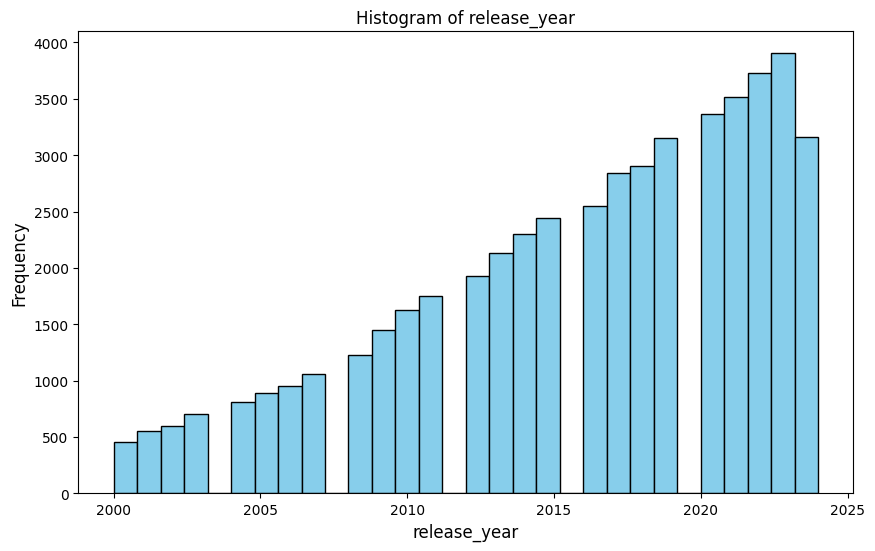

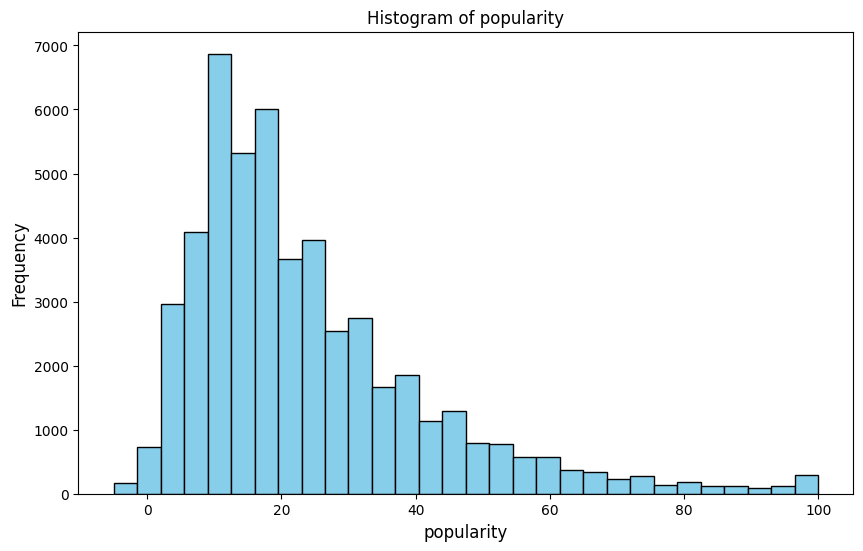

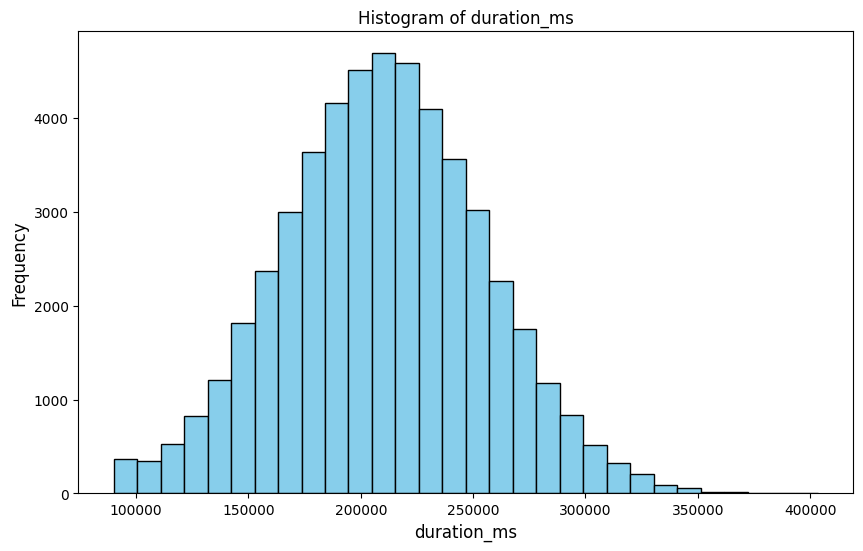

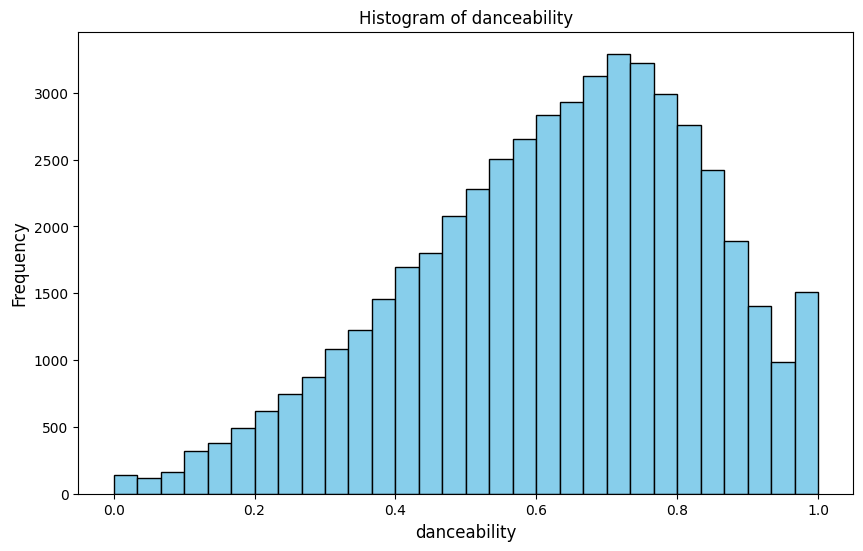

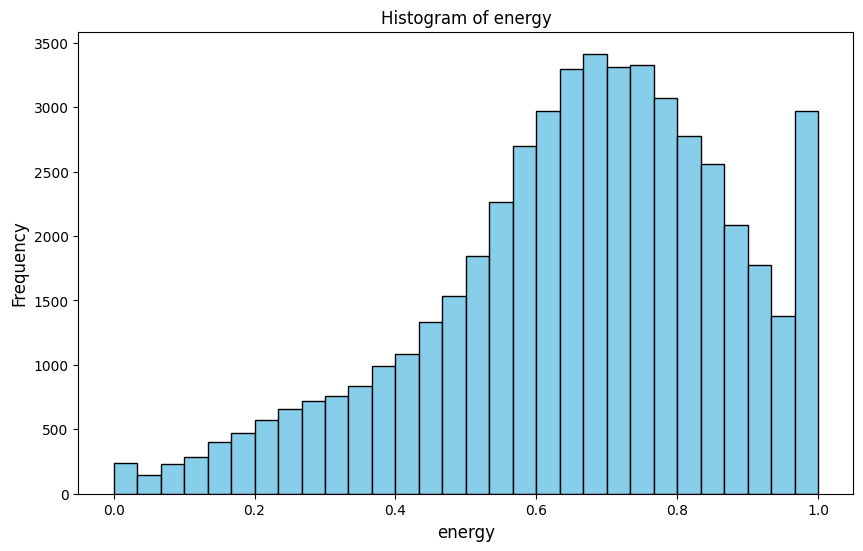

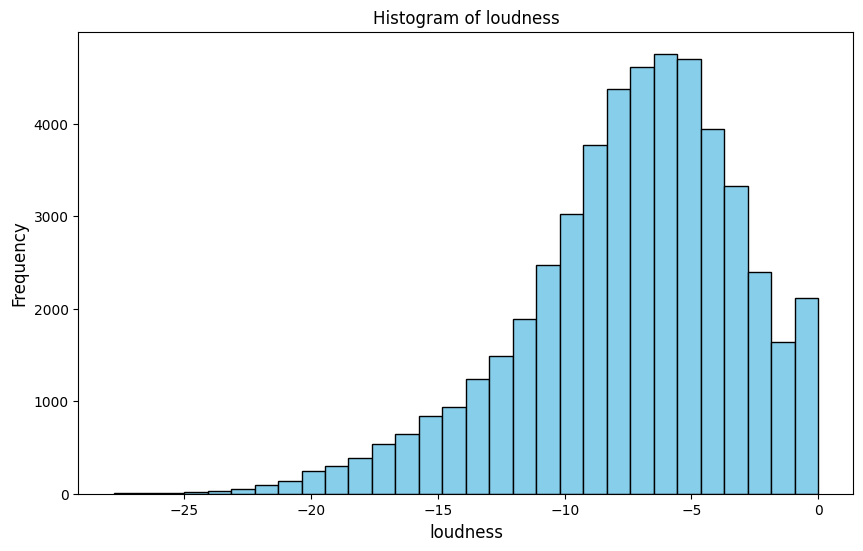

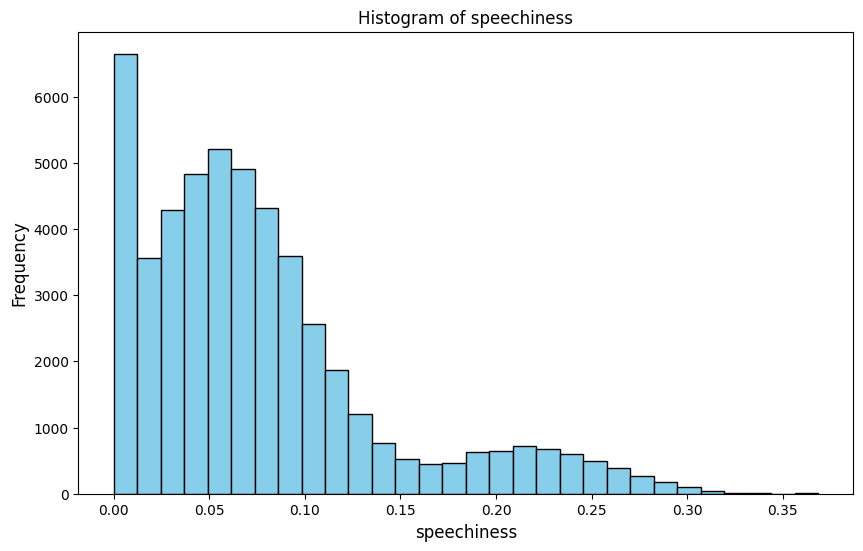

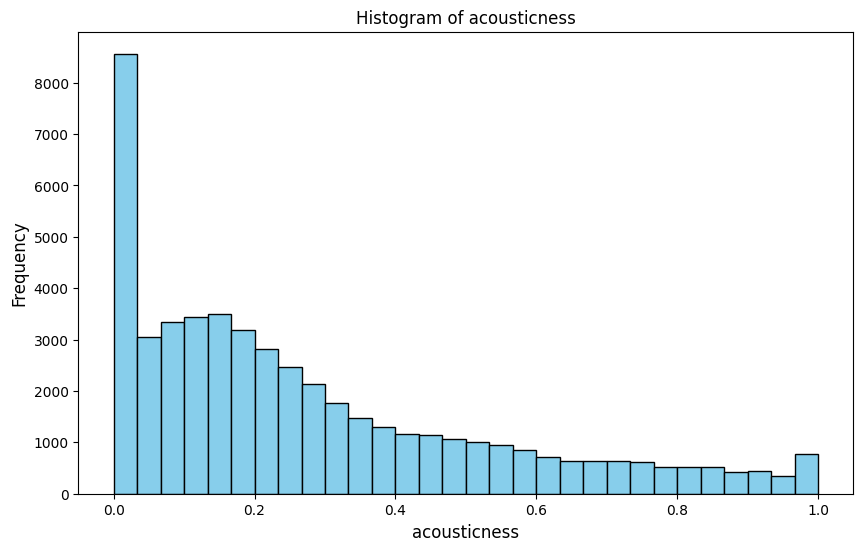

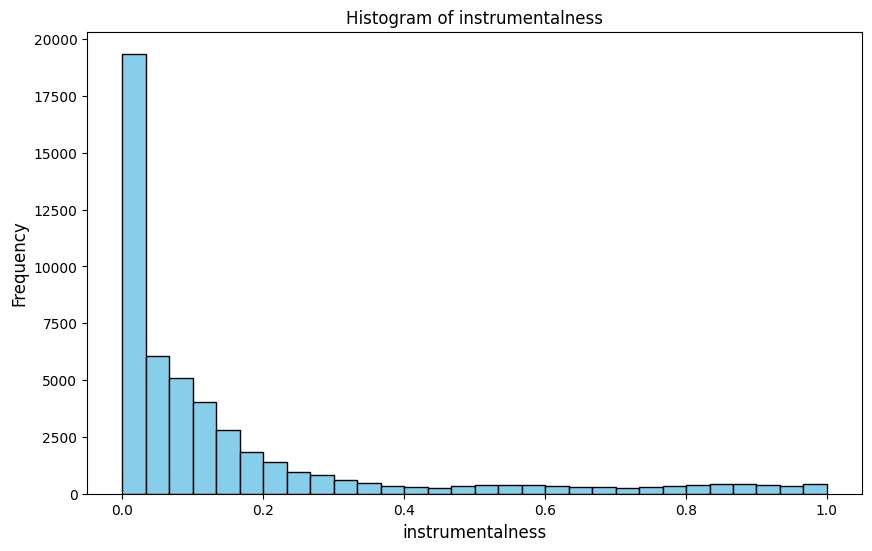

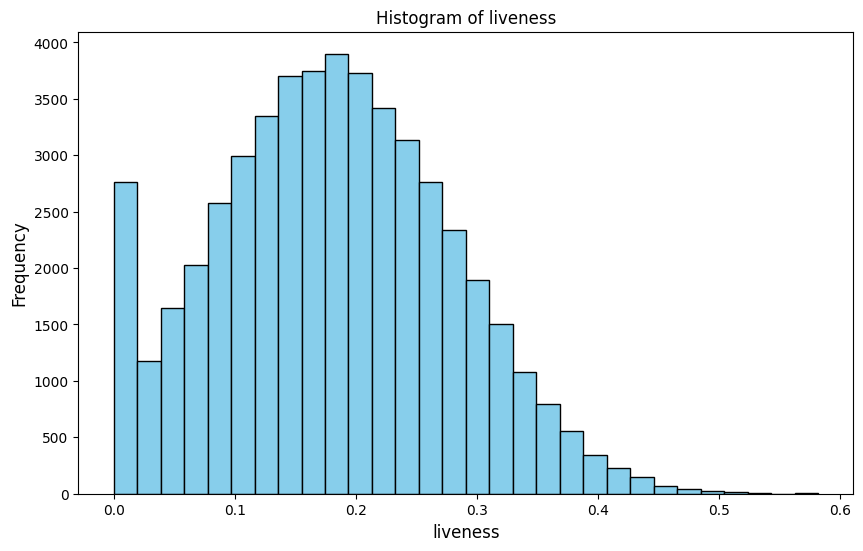

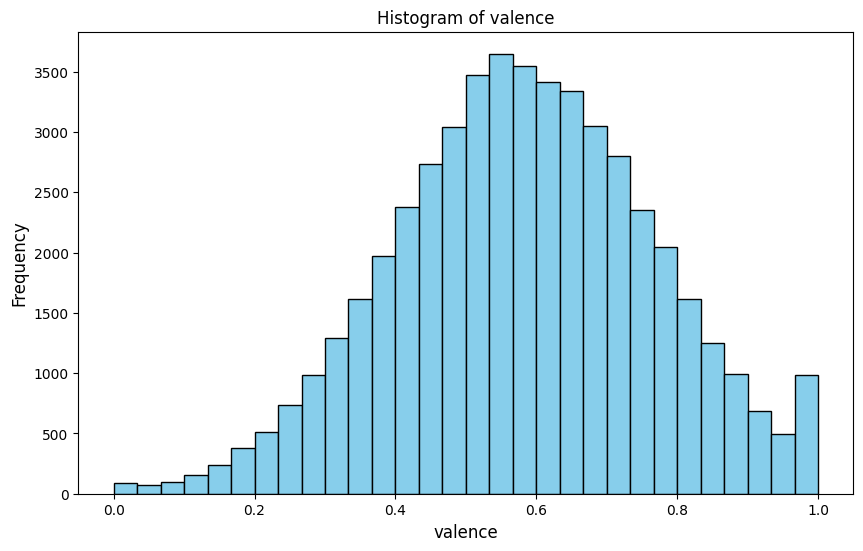

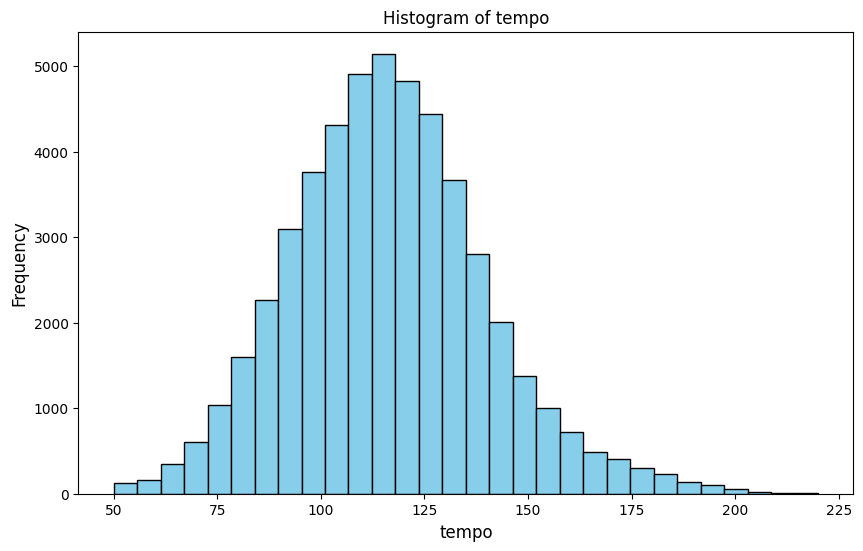

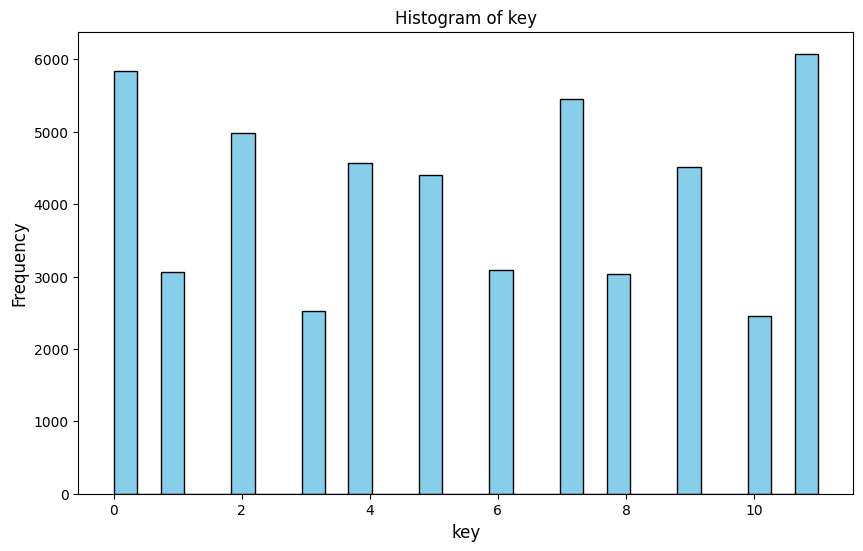

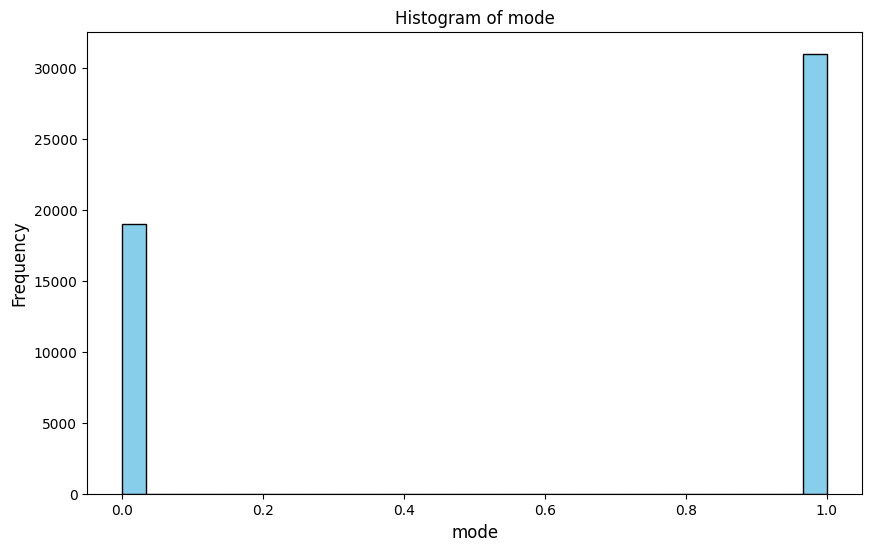

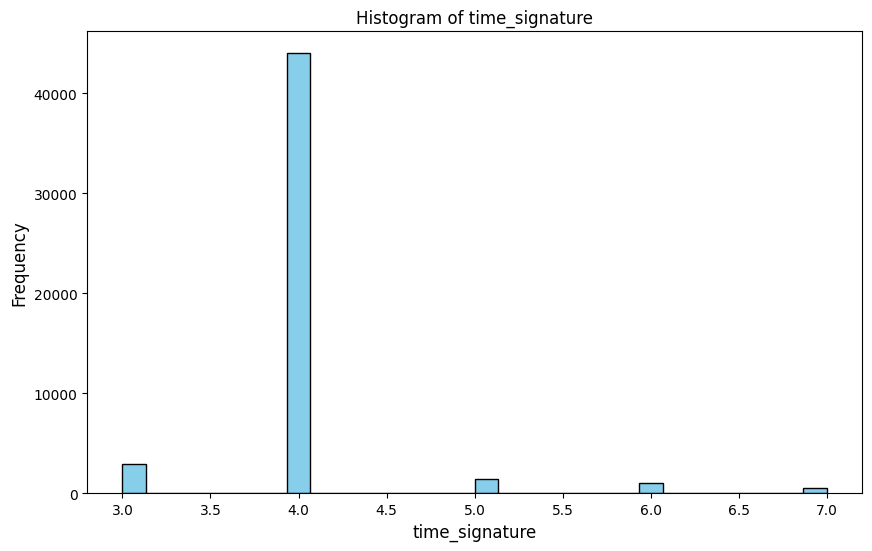

In [ ]:
numerical_cols = dataset.select_dtypes(include=['number']).columns
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    plt.hist(dataset[col], bins=30 ,color='skyblue', edgecolor = 'black')

    #title and labels
    plt.title(f'Histogram of {col}')
    plt.xlabel(col,fontsize = 12)
    plt.ylabel('Frequency',fontsize = 12)
    plt.show()

## Histogram for categorical column

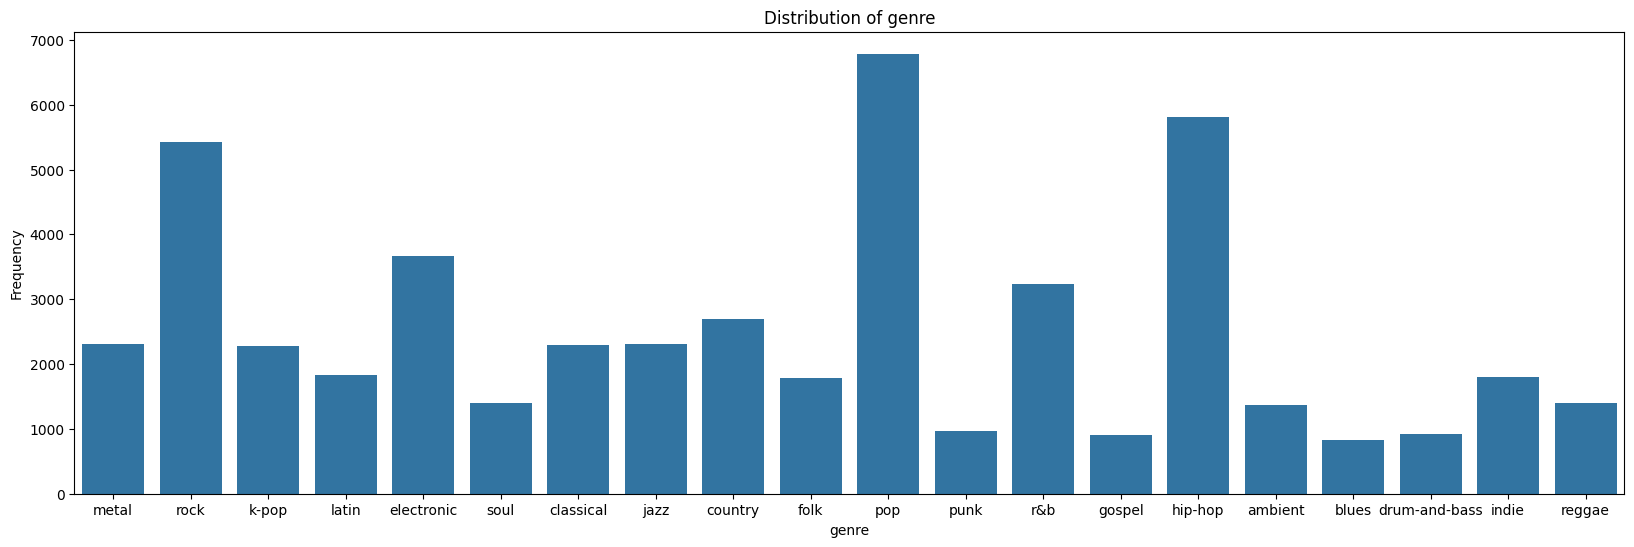

In [ ]:
categorical_cols = ['genre']
for col in categorical_cols:
    plt.figure(figsize=(20, 6))
    sns.countplot(x=col, data=dataset)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Checking for Outlier

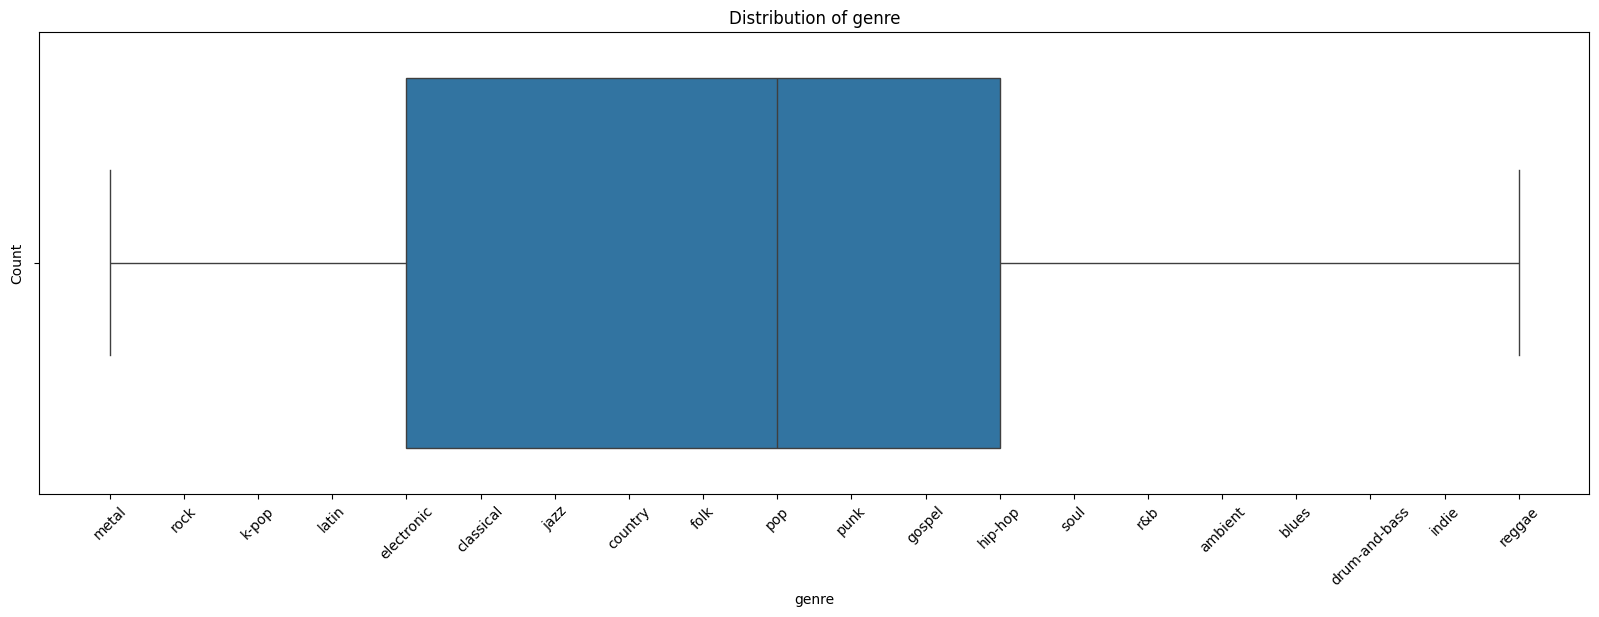

In [ ]:
categorical_cols = ['genre']
for col in categorical_cols:
    plt.figure(figsize=(20, 6))
    sns.boxplot(x=col, data=dataset)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)  # helps if there are many genres
    plt.show()

## Handling Outlier

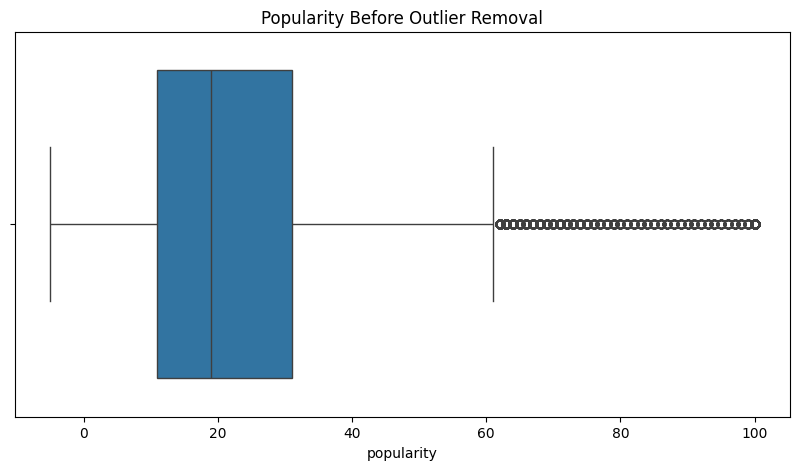

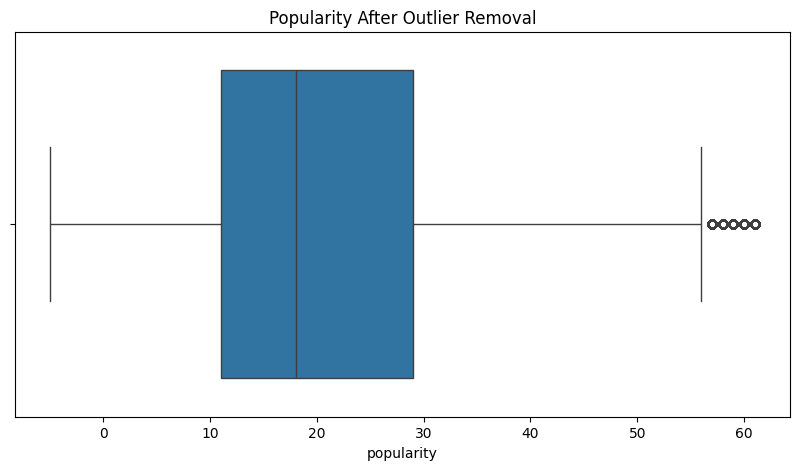

In [ ]:
def handle_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data
plt.figure(figsize=(10,5))
sns.boxplot(x=dataset['popularity'])
plt.title("Popularity Before Outlier Removal")
plt.show()

dataset = handle_outliers_iqr(dataset, 'popularity')
plt.figure(figsize=(10,5))
sns.boxplot(x=dataset['popularity'])
plt.title("Popularity After Outlier Removal")
plt.show()


## Popularity of Music Genres

Popularity of Genres (2000-2010):
        genre  popularity
0   classical   18.197727
1       blues   18.025157
2        folk   17.755435
3       indie   17.755043
4     hip-hop   17.752902
5        rock   17.696714
6        jazz   17.691207
7     ambient   17.689516
8  electronic   17.663730
9         pop   17.454282


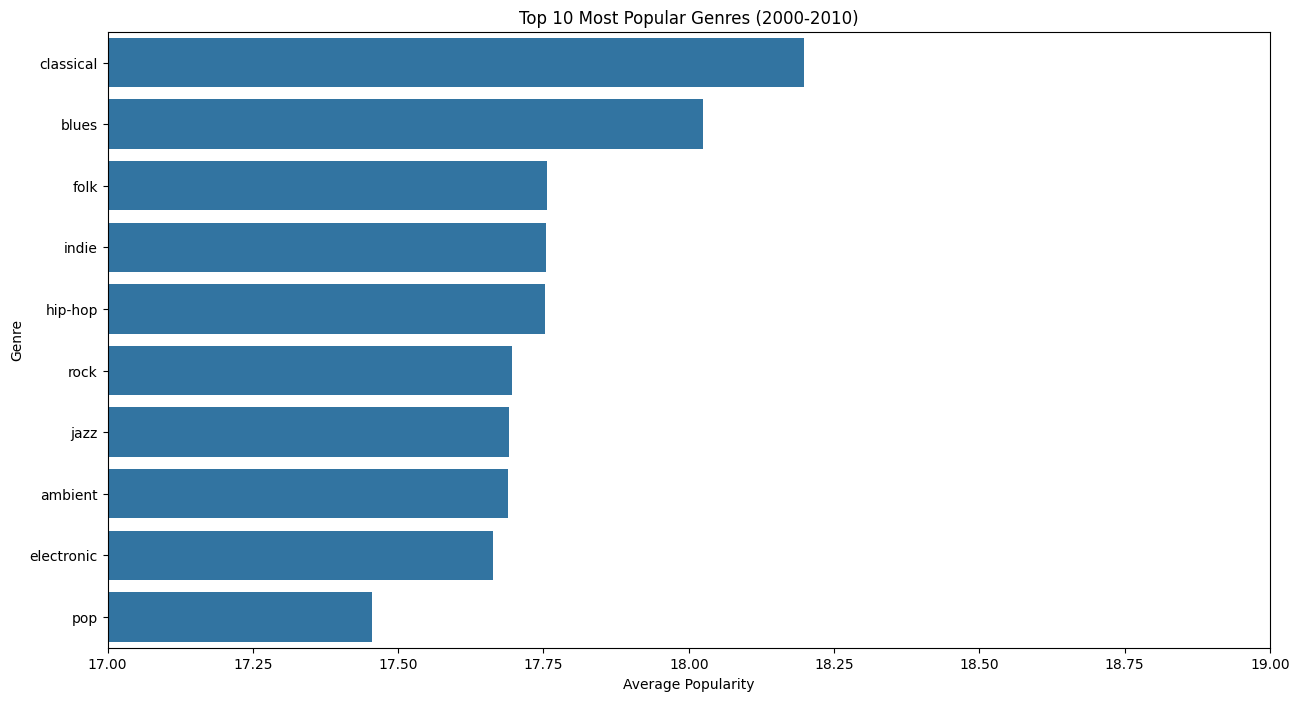

In [ ]:
data_2000_2010 = dataset[(dataset['release_year'] >= 2000) & (dataset['release_year'] <= 2010)]
genre_popularity = data_2000_2010.groupby('genre')['popularity'].mean().sort_values(ascending=False).reset_index()

print("Popularity of Genres (2000-2010):")
print(genre_popularity.head(10))

plt.figure(figsize=(15, 8))
sns.barplot(x='popularity', y='genre', data=genre_popularity.head(10))

plt.title('Top 10 Most Popular Genres (2000-2010)')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')

# popularity range
plt.xlim(17, 19)

plt.show()

Popularity of Genres (2010-2020):
        genre  popularity
0        rock   21.600848
1     ambient   21.556579
2        soul   21.261299
3     country   21.243715
4      reggae   21.239669
5     hip-hop   21.131490
6       latin   21.076440
7         pop   20.869041
8       indie   20.861364
9  electronic   20.856701


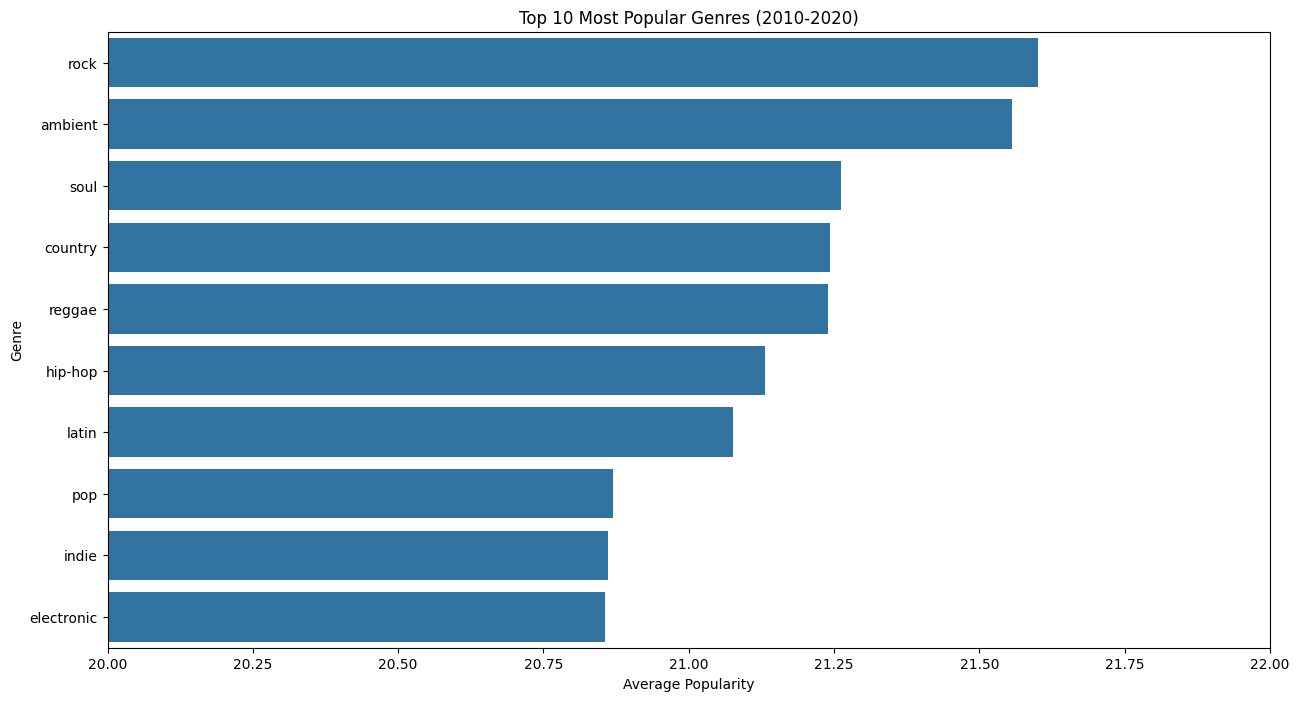

In [ ]:
data_2010_2020 = dataset[(dataset['release_year'] >= 2010) & (dataset['release_year'] <= 2020)]
genre_popularity_2010_2020 = data_2010_2020.groupby('genre')['popularity'].mean().sort_values(ascending=False).reset_index()

print("Popularity of Genres (2010-2020):")
print(genre_popularity_2010_2020.head(10))

plt.figure(figsize=(15, 8))
sns.barplot(x='popularity', y='genre', data=genre_popularity_2010_2020.head(10))

plt.title('Top 10 Most Popular Genres (2010-2020)')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.xlim(20, 22)

plt.show()

Popularity of Genres (2020-2024):
     genre  popularity
0   gospel   24.911854
1     jazz   24.508197
2     soul   24.340292
3   reggae   24.283224
4    blues   24.262458
5     rock   23.958804
6    metal   23.916667
7  ambient   23.912844
8     punk   23.549689
9    latin   23.380560


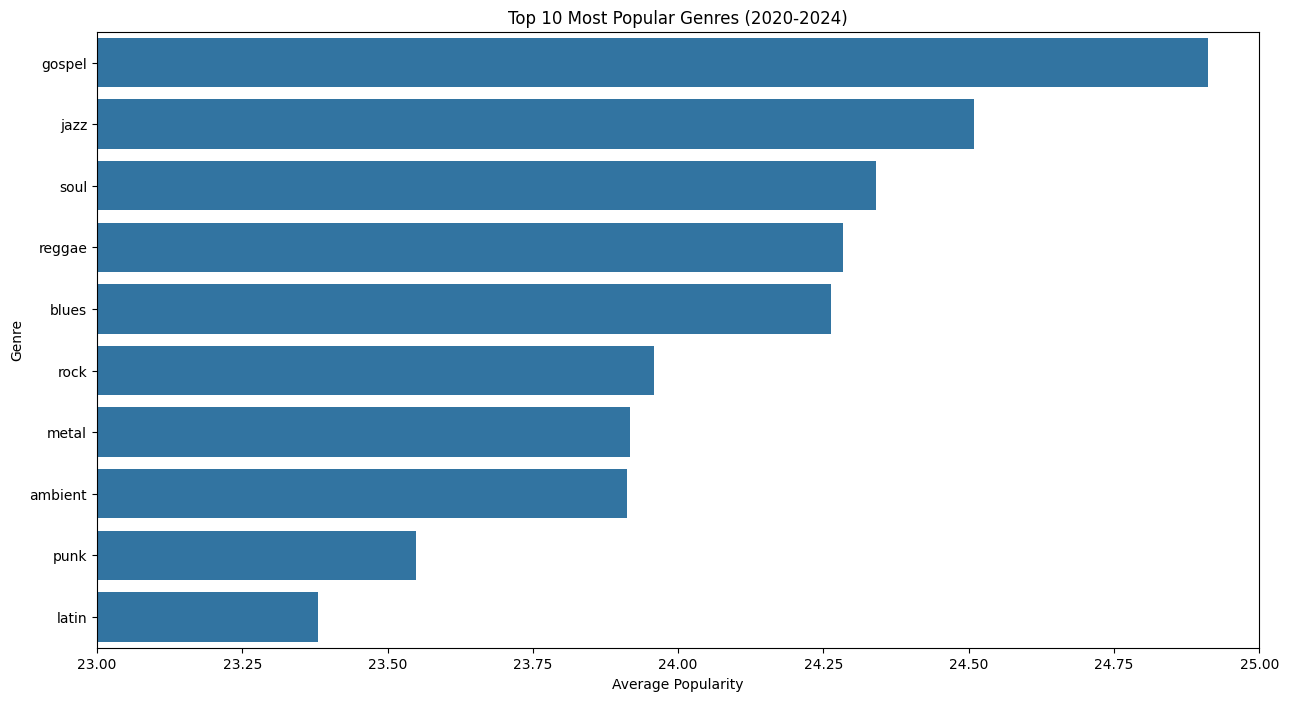

In [ ]:
data_2020_2024 = dataset[(dataset['release_year'] >= 2020) & (dataset['release_year'] <= 2024)]
genre_popularity_2020_2024 = data_2020_2024.groupby('genre')['popularity'].mean().sort_values(ascending=False).reset_index()

print("Popularity of Genres (2020-2024):")
print(genre_popularity_2020_2024.head(10))

plt.figure(figsize=(15, 8))
sns.barplot(x='popularity', y='genre', data=genre_popularity_2020_2024.head(10))

plt.title('Top 10 Most Popular Genres (2020-2024)')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
#popularity range
plt.xlim(23, 25)
plt.show()

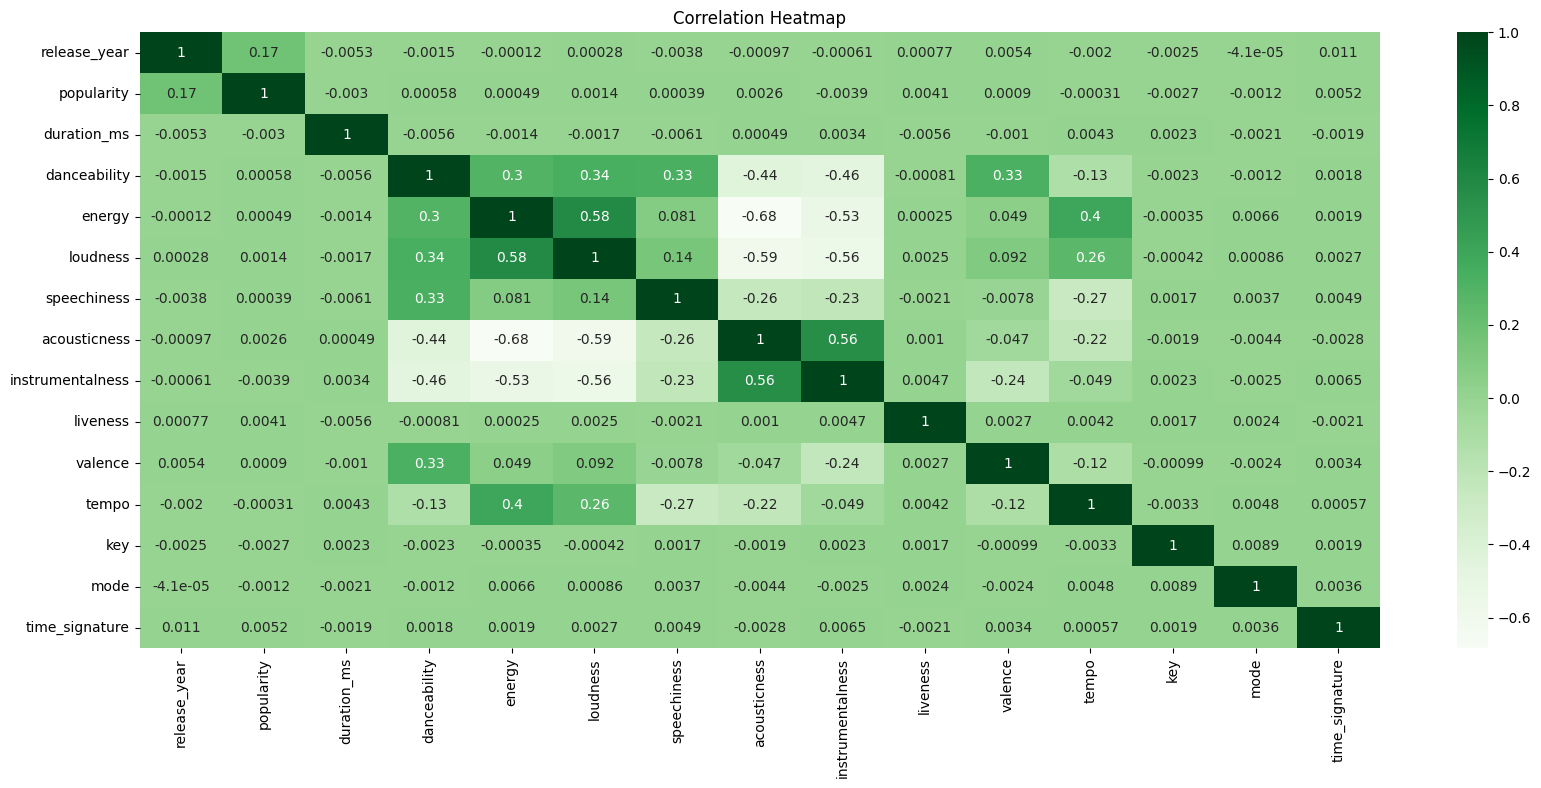

In [ ]:
numeric_dataset = dataset.select_dtypes(include=['number'])
correlation_matrix = numeric_dataset.corr()

plt.figure(figsize=(20,8))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens')

plt.title("Correlation Heatmap")
plt.show()